In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from scipy import fftpack

In [2]:
img = cv2.imread("C:\\Users\\ayush\\OneDrive\\Desktop\\_\\Codes\\CP 4 Lab\\test_cat.png", cv2.IMREAD_GRAYSCALE)

# fourier transform for 2D image
f_img = fftpack.fft2(img)
f_img_shift = fftpack.fftshift(f_img)
# print(f_img)
# print(f_img_shift)

print(f"shape of Image: {img.shape}")
print(f"shape of Fourier coefficients array: {f_img.shape}")

shape of Image: (360, 360)
shape of Fourier coefficients array: (360, 360)


In [3]:
# k upperlimit value
k_x = 50
k_y = 50

row, col = img.shape
c_row, c_col = row // 2, col // 2

# A mask matrix to keep only low frequencies in the middle
m = np.zeros((row, col))
m[c_row - k_y:c_row + k_y, c_col - k_x:c_col + k_x] = 1

ff_img = f_img_shift * m

# Transforming back to image
ff_img_shift = fftpack.ifftshift(ff_img)
img_f = fftpack.ifft2(ff_img_shift)
img_f = np.real(img_f)

# kept coefficients
total_coe = row * col
kept_coe = (2 * k_x) * (2 * k_y)
per = (kept_coe / total_coe) * 100

print(f"k upperlimit in x-direction: {k_x}")
print(f"k upperlimit in y-direction: {k_y}")
print(f"Percentage of kept coefficients: {per} %")

k upperlimit in x-direction: 50
k upperlimit in y-direction: 50
Percentage of kept coefficients: 7.716049382716049 %


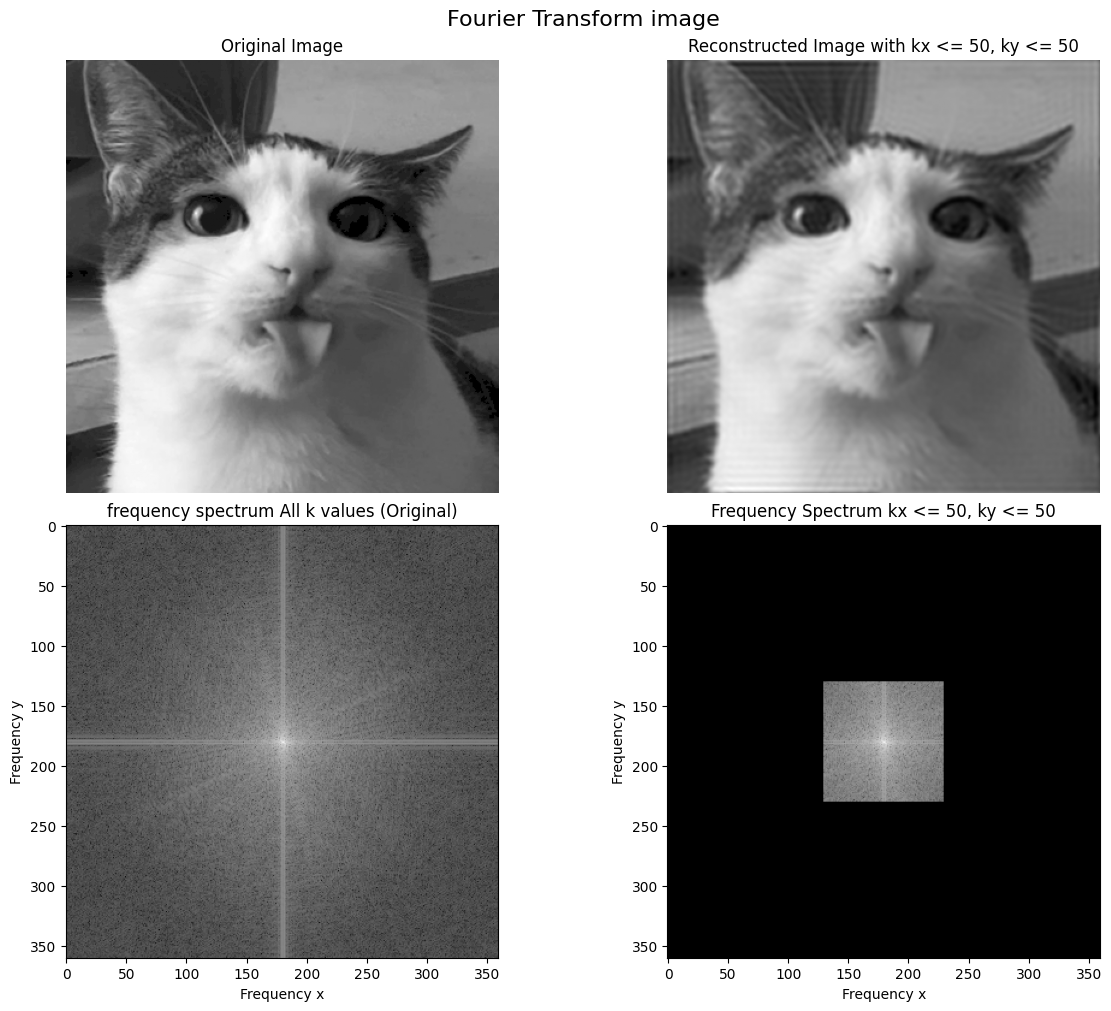

Highest k value in x: 50
Highest k value in y: 50


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)
fig.suptitle(f"Fourier Transform image", fontsize=16)

# Original Image
axes[0, 0].imshow(img, cmap='gray')
axes[0, 0].set_title('Original Image')
axes[0, 0].axis('off')

# New Image with kx <= 50 and ky <= 50
axes[0, 1].imshow(img_f, cmap='gray')
axes[0, 1].set_title(f'Reconstructed Image with kx <= {k_x}, ky <= {k_y}')
axes[0, 1].axis('off')

# Original Frequency Spectrum
axes[1, 0].imshow(np.log(1 + np.abs(f_img_shift)), cmap='grey')
axes[1, 0].set_title('frequency spectrum All k values (Original)')
axes[1, 0].set_xlabel('Frequency x')
axes[1, 0].set_ylabel('Frequency y')

# Frequency Spectrum with kx <= 50 and ky <= 50
axes[1, 1].imshow(np.log(1 + np.abs(ff_img)), cmap='grey')
axes[1, 1].set_title(f'Frequency Spectrum kx <= {k_x}, ky <= {k_y}')
axes[1, 1].set_xlabel('Frequency x')
axes[1, 1].set_ylabel('Frequency y')

plt.show()

print(f"Highest k value in x: {k_x}")
print(f"Highest k value in y: {k_y}")